## Import Libraries

In [1]:
import sys
import importlib
import joblib
import pandas as pd
from matplotlib.ticker import MultipleLocator, ScalarFormatter
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib.ticker import ScalarFormatter
import tensorflow as tf
from matplotlib.backends.backend_pdf import PdfPages
from tqdm import tqdm
from matplotlib.ticker import MaxNLocator
import matplotlib.ticker as mticker

2026-09-09 13:51:06.591386: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-09 13:51:06.625623: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-09-09 13:51:06.625652: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-09-09 13:51:06.626886: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-09-09 13:51:06.634002: I tensorflow/core/platform/cpu_feature_guar

## Data Preparation

In [2]:
sys.path.append("../analysis_tools")

In [3]:
from data_extraction import DataExtraction1D

In [4]:
file_path = '../Data/1d_SWAN_Data/1d_DON_training.txt'
extractor = DataExtraction1D()
data_df = extractor.read_data_txt(file_path)

In [5]:
print(data_df)

        wind  wind_direction  initial_wave_h  initial_wave_d     dist  \
0         11             353             0.6             353      0.0   
1         11             353             0.6             353    100.0   
2         11             353             0.6             353    200.0   
3         11             353             0.6             353    300.0   
4         11             353             0.6             353    400.0   
...      ...             ...             ...             ...      ...   
902771    17               7             1.2               7  37100.0   
902772    17               7             1.2               7  37200.0   
902773    17               7             1.2               7  37300.0   
902774    17               7             1.2               7  37400.0   
902775    17               7             1.2               7  37500.0   

          depth     Hsig  RTpeak    Tm01    Tm02      FSpr      Dir  x_wforce  \
0       40.0000  0.59949  3.3437  2.8850  

In [6]:
import pickle
with open("../Data/1d_SWAN_Data/1d_dataset.pkl", "rb") as f:
    loaded_data = pickle.load(f)

train_set = loaded_data["train"]
val_set = loaded_data["val"]
test_set = loaded_data["test"]

In [7]:
test_combination_df = pd.DataFrame(test_set, columns=["Wind Value", "Wind Direction", "Wave Height", "Wave Direction"])
print(test_combination_df)

     Wind Value  Wind Direction  Wave Height  Wave Direction
0            15             356          1.1             353
1            16             354          0.6               6
2            14               7          1.2               7
3            17             356          0.7               0
4            13               0          0.7               0
..          ...             ...          ...             ...
356          13               4          1.0               4
357          13               7          0.9             356
358          14             354          1.2               7
359          11             356          0.6               4
360          12             356          0.8             354

[361 rows x 4 columns]


## Load functions

In [8]:
def get_result(data_df, wind_value,direction_value,initial_wave_h_value,initial_wave_d_value,loc):

    filtered_df = data_df[
        (data_df['wind'] == wind_value) &
        (data_df['wind_direction'] == direction_value) &
        (data_df['initial_wave_h'] == initial_wave_h_value) &
        (data_df['initial_wave_d'] == initial_wave_d_value)
    ]
    if loc != 'entire':
        return filtered_df['x_wforce'].iloc[loc], filtered_df['y_wforce'].iloc[loc], filtered_df['Hsig'].iloc[loc], filtered_df['dist'].iloc[loc]
    else:
        return filtered_df['x_wforce'], filtered_df['y_wforce'], filtered_df['Hsig'], filtered_df['dist']

import itertools

def convert_wind_components(speed, direction):
    # Convert wind direction to radians
    direction_rad = np.deg2rad(direction)
    # Calculate x and y components of the wind speed
    x_wind = speed * np.cos(direction_rad)
    y_wind = speed * np.sin(direction_rad)
    return x_wind, y_wind
    
def load_and_scale_new_data(new_b_train, scaler_path_0_1, scaler_path_2):
    """
    Load the saved scalers and apply scaling to new data.
    
    Parameters:
    - new_b_train: np.array, new input data.
    - scaler_path_0_1: str, path to load MinMaxScaler for columns 0 and 1.
    - scaler_path_2: str, path to load MinMaxScaler for column 2.
    
    Returns:
    - new_b_train_scaled: np.array, scaled new data.
    """
    # Load the saved MinMaxScaler for columns 0 and 1
    scaler_0_1 = joblib.load(scaler_path_0_1)
    
    # Load the saved MinMaxScaler for column 2
    scaler_2 = joblib.load(scaler_path_2)
    
    # # Load the custom scaling factor for column 3
    # scaling_factor_3 = joblib.load(scaler_path_3)
    
    # Apply scaling to columns 0 and 1 using the loaded scaler
    new_scaled_0_1 = scaler_0_1.transform(new_b_train[:, [0, 1]])
    
    # Apply scaling to column 2 using the loaded scaler
    new_scaled_2 = scaler_2.transform(new_b_train[:, [2]].reshape(-1, 1))
    
    
    # Combine the scaled columns back together
    new_b_train_scaled = np.hstack((new_scaled_0_1, new_scaled_2, new_b_train[:, [3, 4]]))
    
    return new_b_train_scaled


## Hsig Senstivity Analysis

In [9]:
import os
import joblib
import numpy as np
import tensorflow as tf

# Define the sampling tiers and their directories
sampling_tiers = ["1p", "5p", "10p", "20p", "100p"]
sensitivity_results = {}

for p in sampling_tiers:
    print(f"--- Processing {p} Sampling Tier ---")
    
    # 1. Path setup exactly as you have it
    if p == "5p":
        model_dir = f'../sampling_sensitivity_models/Models/Hsig/1d_model_Hsig_new'   
    else:
        model_dir = f'../sampling_sensitivity_models/Models/Hsig/{p}/Model_1D_{p}'
    
    # Reset lists for this specific tier
    absolute_error_list = []
    scenario_list = []
    ground_true = []
    predictions_list = []
    target_name = 'hsig' # or 'x_force'

    # Load scalers and model
    t_scaler = joblib.load(os.path.join(model_dir, 't_scaler.pkl'))
    target_scaler = joblib.load(os.path.join(model_dir, 'target_scaler.pkl'))
    if p == "5p":
        load_model = tf.keras.models.load_model(model_dir, compile=False)
    else:
        model_path = os.path.join(model_dir, 'model')
        load_model = tf.keras.models.load_model(model_path, compile=False)

    # 2. Run Inference Loop (Identical Logic)
    for idx, row in test_combination_df.iterrows():
        x_wforce, y_wforce, hsig, dist_x = get_result(data_df, row['Wind Value'], row['Wind Direction'], 
                                                      row['Wave Height'], row['Wave Direction'], loc='entire')
        
        x_wind, y_wind = convert_wind_components(row['Wind Value'], row['Wind Direction'])
        cos_wave_dir = np.cos(np.radians(row['Wave Direction']))
        sin_wave_dir = np.sin(np.radians(row['Wave Direction']))
        
        b_test_input = [x_wind, y_wind, row['Wave Height'], cos_wave_dir, sin_wave_dir]
        b_test_input = np.array([b_test_input for _ in range(len(dist_x))])
        
        b_test = load_and_scale_new_data(
            b_test_input,
            scaler_path_0_1=f'{model_dir}/scaler_factor_0_1.pkl',
            scaler_path_2=f'{model_dir}/scaler_factor_2.pkl'
        )
        
        t_test_input = dist_x.values.reshape(-1, 1)
        t_test = t_scaler.transform(t_test_input)
    
        if target_name == 'hsig':
            target_input = hsig.values.reshape(-1, 1)
        elif target_name == 'x_force':
            target_input = x_wforce.values.reshape(-1, 1) 
        elif target_name == 'y_force':
            target_input = y_wforce.values.reshape(-1, 1) 
        
        # Use functional call to avoid Keras predict cardinality errors if necessary
        o_res = load_model([b_test, t_test])
        o_res = target_scaler.inverse_transform(o_res)
        
        predictions_list.append(o_res)
        scenario_list.append([row['Wind Value'], row['Wind Direction'], row['Wave Height'], row['Wave Direction']])
        
        absolute_error = abs(o_res - target_input)
        ground_true.append(target_input)
        absolute_error_list.append(absolute_error)

    # 3. Calculate Relative L2 List
    rel_l2_list = []
    for true_vec, ae_vec in zip(ground_true, absolute_error_list):
        l2_diff = np.linalg.norm(ae_vec)
        l2_truth = np.linalg.norm(true_vec)
        rel_l2 = (l2_diff / l2_truth) if l2_truth > 1e-9 else 0.0
        rel_l2_list.append(rel_l2)

    rel_l2_arr = np.array(rel_l2_list)
    sorted_indices = np.argsort(rel_l2_arr)

    # Get Top 3 Best and Worst
    best_3_idxs = sorted_indices[:3]
    worst_3_idxs = sorted_indices[-3:][::-1]

    # helper to package the data
    def package_metrics(indices):
        results = []
        for i in indices:
            ae_vec = absolute_error_list[i].flatten()
            results.append({
                "idx": i,
                "info": scenario_list[i],
                "max_ae": np.max(ae_vec),
                "mean_ae": np.mean(ae_vec),
                "rmse": np.sqrt(np.mean(ae_vec**2)),
                "rel_l2": rel_l2_arr[i] * 100
            })
        return results

    # Save to the sensitivity results dictionary
    sensitivity_results[p] = {
        "best": package_metrics(best_3_idxs),
        "worst": package_metrics(worst_3_idxs),
        "mean_l2": np.mean(rel_l2_arr) * 100
    }

# # --- Final Print Out for Comparison ---
# print(f"\n{'Sampling':<10} | {'Mean L2 (%)':<12} | {'Worst Rel L2':<15} | {'Worst RMSE'}")
# print("-" * 55)
# for p in sampling_tiers:
#     res = sensitivity_results[p]
#     w1 = res['worst'][0] # Absolute worst
#     print(f"{p:<10} | {res['mean_l2']:<12.2f} | {w1['rel_l2']:<15.2f}% | {w1['rmse']:<10.6f}")

--- Processing 1p Sampling Tier ---


/workspace/shukaic/miniconda3/envs/DON/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.8.0 when using version 1.4.1.post1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
2026-09-09 13:51:20.750928: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 43502 MB memory:  -> device: 0, name: NVIDIA L40S, pci bus id: 0000:be:00.0, compute capability: 8.9
/workspace/shukaic/miniconda3/envs/DON/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.8.0 when using version 1.4.1.post1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://

--- Processing 5p Sampling Tier ---


/workspace/shukaic/miniconda3/envs/DON/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.3.0 when using version 1.4.1.post1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/workspace/shukaic/miniconda3/envs/DON/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.3.0 when using version 1.4.1.post1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/workspace/shukaic/miniconda3/envs/DON/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinM

--- Processing 10p Sampling Tier ---


/workspace/shukaic/miniconda3/envs/DON/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.8.0 when using version 1.4.1.post1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/workspace/shukaic/miniconda3/envs/DON/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.8.0 when using version 1.4.1.post1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/workspace/shukaic/miniconda3/envs/DON/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinM

--- Processing 20p Sampling Tier ---


/workspace/shukaic/miniconda3/envs/DON/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.8.0 when using version 1.4.1.post1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/workspace/shukaic/miniconda3/envs/DON/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.8.0 when using version 1.4.1.post1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/workspace/shukaic/miniconda3/envs/DON/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinM

--- Processing 100p Sampling Tier ---


/workspace/shukaic/miniconda3/envs/DON/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.8.0 when using version 1.4.1.post1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/workspace/shukaic/miniconda3/envs/DON/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.8.0 when using version 1.4.1.post1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/workspace/shukaic/miniconda3/envs/DON/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinM

In [10]:
# --- Printing the Worst 3 Scenarios for All Tiers ---

print("="*80)
print(f"{'SAMPLING':<10} | {'RANK':<5} | {'REL L2 (%)':<12} | {'RMSE':<12} | {'SCENARIO INFO (Wind/Wave)'}")
print("="*80)

for p in ["1p", "5p", "10p", "20p", "100p"]:
    if p in sensitivity_results:
        # Loop through the list of 3 best scenarios saved for this tier
        for rank, res in enumerate(sensitivity_results[p]['worst'], 1):
            info = res['info']
            # Format: Wind Speed, Wind Dir, Wave Height, Wave Dir
            scen_str = f"W:{info[0]}m/s {info[1]}° | H:{info[2]}m {info[3]}°"
            
            # Print the row
            print(f"{p:<10} | #{rank:<4} | {res['rel_l2']:<12.2f} | {res['rmse']:<12.6f} | {scen_str}")
        
        # Add a small separator between sampling sizes for readability
        print("-" * 80)

SAMPLING   | RANK  | REL L2 (%)   | RMSE         | SCENARIO INFO (Wind/Wave)
1p         | #1    | 0.75         | 0.008617     | W:11.0m/s 353.0° | H:0.9m 6.0°
1p         | #2    | 0.59         | 0.007078     | W:11.0m/s 353.0° | H:1.2m 6.0°
1p         | #3    | 0.51         | 0.007942     | W:15.0m/s 354.0° | H:0.7m 354.0°
--------------------------------------------------------------------------------
5p         | #1    | 0.72         | 0.008305     | W:11.0m/s 353.0° | H:0.9m 6.0°
5p         | #2    | 0.54         | 0.007133     | W:13.0m/s 356.0° | H:0.6m 0.0°
5p         | #3    | 0.47         | 0.005714     | W:11.0m/s 353.0° | H:1.2m 6.0°
--------------------------------------------------------------------------------
10p        | #1    | 0.63         | 0.007202     | W:11.0m/s 353.0° | H:0.9m 6.0°
10p        | #2    | 0.53         | 0.007060     | W:13.0m/s 356.0° | H:0.6m 0.0°
10p        | #3    | 0.50         | 0.005970     | W:11.0m/s 353.0° | H:1.2m 6.0°
---------------------

In [11]:
# --- Printing the Best 3 Scenarios for All Tiers ---

print("="*80)
print(f"{'SAMPLING':<10} | {'RANK':<5} | {'REL L2 (%)':<12} | {'RMSE':<12} | {'SCENARIO INFO (Wind/Wave)'}")
print("="*80)

for p in ["1p", "5p", "10p", "20p", "100p"]:
    if p in sensitivity_results:
        # Loop through the list of 3 best scenarios saved for this tier
        for rank, res in enumerate(sensitivity_results[p]['best'], 1):
            info = res['info']
            # Format: Wind Speed, Wind Dir, Wave Height, Wave Dir
            scen_str = f"W:{info[0]}m/s {info[1]}° | H:{info[2]}m {info[3]}°"
            
            # Print the row
            print(f"{p:<10} | #{rank:<4} | {res['rel_l2']:<12.2f} | {res['rmse']:<12.6f} | {scen_str}")
        
        # Add a small separator between sampling sizes for readability
        print("-" * 80)

SAMPLING   | RANK  | REL L2 (%)   | RMSE         | SCENARIO INFO (Wind/Wave)
1p         | #1    | 0.15         | 0.002703     | W:17.0m/s 0.0° | H:1.0m 353.0°
1p         | #2    | 0.16         | 0.002887     | W:17.0m/s 356.0° | H:1.0m 0.0°
1p         | #3    | 0.17         | 0.002964     | W:17.0m/s 356.0° | H:0.9m 4.0°
--------------------------------------------------------------------------------
5p         | #1    | 0.10         | 0.001471     | W:14.0m/s 4.0° | H:0.6m 0.0°
5p         | #2    | 0.11         | 0.001972     | W:17.0m/s 356.0° | H:0.9m 4.0°
5p         | #3    | 0.11         | 0.002026     | W:17.0m/s 356.0° | H:1.1m 6.0°
--------------------------------------------------------------------------------
10p        | #1    | 0.08         | 0.001238     | W:14.0m/s 6.0° | H:0.8m 4.0°
10p        | #2    | 0.11         | 0.001761     | W:16.0m/s 0.0° | H:0.8m 0.0°
10p        | #3    | 0.11         | 0.001842     | W:16.0m/s 353.0° | H:1.1m 4.0°
-----------------------------

In [12]:
print("--- Average Relative L2 Error per Sampling Tier ---")
print(f"{'Sampling Tier':<15} | {'Avg Rel L2 Error (%)':<20}")
print("-" * 40)

for tier in ["1p", "5p", "10p", "20p", "100p"]:
    if tier in sensitivity_results:
        avg_error = sensitivity_results[tier]['mean_l2']
        print(f"{tier:<15} | {avg_error:<20.2f}%")

--- Average Relative L2 Error per Sampling Tier ---
Sampling Tier   | Avg Rel L2 Error (%)
----------------------------------------
1p              | 0.27                %
5p              | 0.22                %
10p             | 0.21                %
20p             | 0.22                %
100p            | 0.23                %


In [13]:
runtime_seconds = {
    "1p": 6*60 + 29,
    "5p": 26*60 + 41,
    "10p": 51*60 + 45,
    "20p": 1*3600 + 43*60 + 22,
    "100p": 8*3600 + 33*60 + 20
}

In [14]:
print(sensitivity_results['1p'])

{'best': [{'idx': 353, 'info': [17.0, 0.0, 1.0, 353.0], 'max_ae': 0.021964725596308687, 'mean_ae': 0.0019878837794287457, 'rmse': 0.00270267927933959, 'rel_l2': 0.15003505358977975}, {'idx': 293, 'info': [17.0, 356.0, 1.0, 0.0], 'max_ae': 0.027008409449458037, 'mean_ae': 0.002044407731472949, 'rmse': 0.0028868002738582236, 'rel_l2': 0.15993942895007132}, {'idx': 206, 'info': [17.0, 356.0, 0.9, 4.0], 'max_ae': 0.0396101944231988, 'mean_ae': 0.0018049914579874094, 'rmse': 0.0029639567922267033, 'rel_l2': 0.16580562881588962}], 'worst': [{'idx': 336, 'info': [11.0, 353.0, 0.9, 6.0], 'max_ae': 0.01621459998965258, 'mean_ae': 0.0071707293122885716, 'rmse': 0.008617494498825045, 'rel_l2': 0.7502203251379959}, {'idx': 244, 'info': [11.0, 353.0, 1.2, 6.0], 'max_ae': 0.01449715641617777, 'mean_ae': 0.005244147312823421, 'rmse': 0.007078053843032805, 'rel_l2': 0.587166961367821}, {'idx': 70, 'info': [15.0, 354.0, 0.7, 354.0], 'max_ae': 0.0326921720635891, 'mean_ae': 0.00550986595562875, 'rmse': 

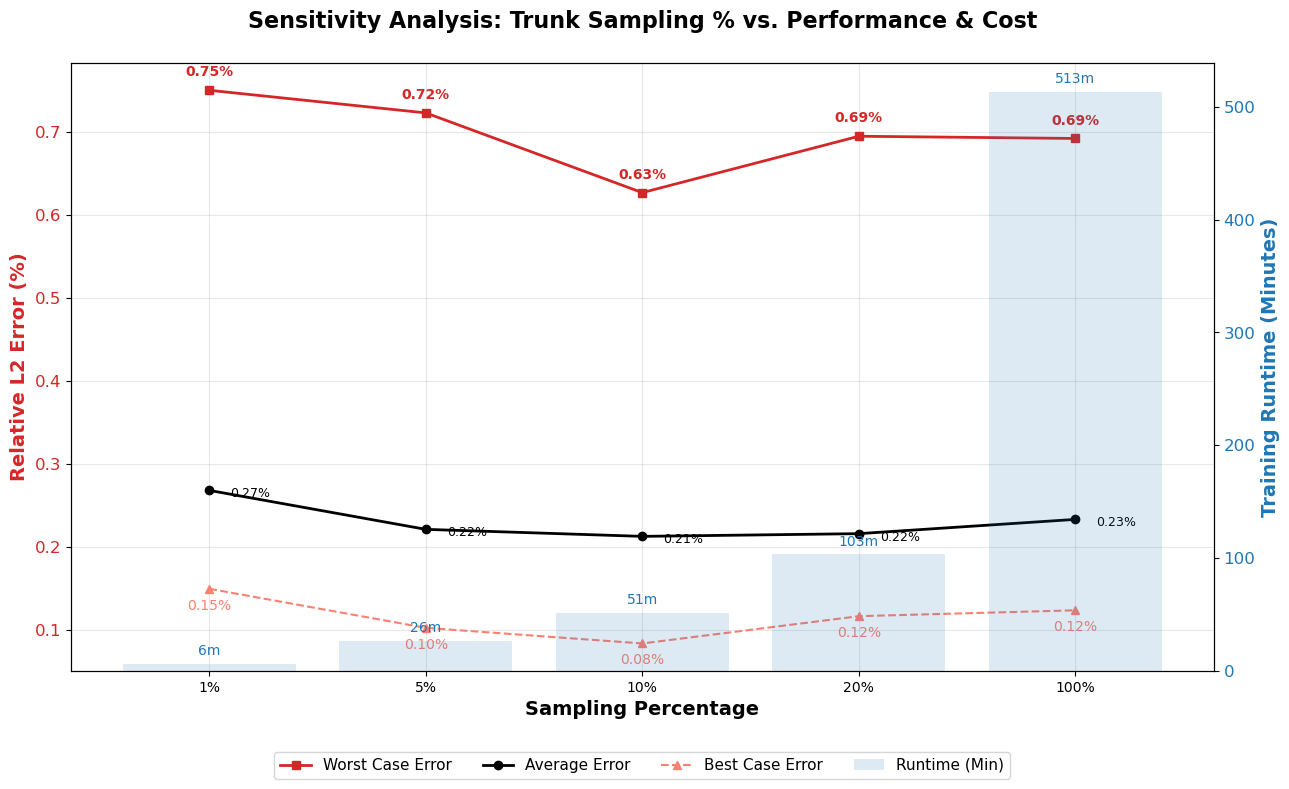

In [15]:
import matplotlib.pyplot as plt

# Data extraction (assuming your dictionaries are populated)
tiers = ["1p", "5p", "10p", "20p", "100p"]
tiers_label = ["1%", "5%", "10%", "20%", "100%"]
best_l2 = [sensitivity_results[t]['best'][0]['rel_l2'] for t in tiers]
worst_l2 = [sensitivity_results[t]['worst'][0]['rel_l2'] for t in tiers]
avg_errors = [sensitivity_results[t]['mean_l2'] for t in tiers]
runtimes = [runtime_seconds[t] / 60 for t in tiers] 

fig, ax1 = plt.subplots(figsize=(13, 8))

# --- Plot Accuracy (Line Chart) ---
ax1.set_xlabel('Sampling Percentage', fontsize=14, fontweight='bold')
ax1.set_ylabel('Relative L2 Error (%)', color='tab:red', fontsize=14, fontweight='bold')

# Plotting the three error lines
line1 = ax1.plot(tiers_label, worst_l2, color='tab:red', marker='s', linewidth=2, label='Worst Case Error')
line2 = ax1.plot(tiers_label, avg_errors, color='black', marker='o', linewidth=2, label='Average Error')
line3 = ax1.plot(tiers_label, best_l2, color='salmon', marker='^', linestyle='--', linewidth=1.5, label='Best Case Error')

ax1.tick_params(axis='y', labelcolor='tab:red', labelsize=12)
ax1.grid(True, alpha=0.3)

# --- Add Data Labels for Errors ---
for i in range(len(tiers_label)):
    # Worst case (Top)
    ax1.annotate(f'{worst_l2[i]:.2f}%', (tiers_label[i], worst_l2[i]), 
                 textcoords="offset points", xytext=(0,10), ha='center', color='tab:red', fontweight='bold')
    # Average (Middle/Side)
    ax1.annotate(f'{avg_errors[i]:.2f}%', (tiers_label[i], avg_errors[i]), 
                 textcoords="offset points", xytext=(15,-5), ha='left', fontsize=9)
    # Best case (Bottom)
    ax1.annotate(f'{best_l2[i]:.2f}%', (tiers_label[i], best_l2[i]), 
                 textcoords="offset points", xytext=(0,-15), ha='center', color='salmon')

# --- Plot Runtime (Bar Chart) ---
ax2 = ax1.twinx() 
ax2.set_ylabel('Training Runtime (Minutes)', color='tab:blue', fontsize=14, fontweight='bold')
bars = ax2.bar(tiers_label, runtimes, color='tab:blue', alpha=0.15, label='Runtime (Min)')
ax2.tick_params(axis='y', labelcolor='tab:blue', labelsize=12)

# --- Add Data Labels for Runtime ---
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{int(height)}m', ha='center', va='bottom', color='tab:blue', fontsize=10)

# --- Final Touches ---
plt.title('Sensitivity Analysis: Trunk Sampling % vs. Performance & Cost', fontsize=16, fontweight='bold', pad=25)

# Combined Legend
all_lines = line1 + line2 + line3
all_labels = [l.get_label() for l in all_lines] + ['Runtime (Min)']
ax1.legend(all_lines + [bars], all_labels, loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=4, fontsize=11)

fig.tight_layout()
plt.savefig('Hsig_different_percentage.pdf')
plt.show()

## Forces Analysis and Model Prediction

## Forces Sensitivity Analysis

In [16]:
import os
import joblib
import numpy as np
import tensorflow as tf

# Define the sampling tiers and their directories
sampling_tiers = ["1p", "5p", "10p", "20p", "100p"]
sensitivity_results = {}

for p in sampling_tiers:
    print(f"--- Processing {p} Sampling Tier ---")
    
    # 1. Path setup exactly as you have it
    if p == "5p":
        model_dir = f'../sampling_sensitivity_models/Models/Forces/1d_model_forces_new'   
    else:
        model_dir = f'../sampling_sensitivity_models/Models/Forces/{p}/Model_1D_{p}'
    # model_dir = f'./Forces_Model_output/{p}/Model_1D_{p}'
    
    # Reset lists for this specific tier
    absolute_error_list = []
    scenario_list = []
    ground_true = []
    predictions_list = []
    target_name = 'x_force' # or 'x_force'

    # Load scalers and model
    t_scaler = joblib.load(os.path.join(model_dir, 't_scaler.pkl'))
    target_scaler = joblib.load(os.path.join(model_dir, 'target_scaler.pkl'))
    
    if p == "5p":
        load_model = tf.keras.models.load_model(model_dir, compile=False)
    else:
        model_path = os.path.join(model_dir, 'model')
        load_model = tf.keras.models.load_model(model_path, compile=False)
    
    # model_path = os.path.join(model_dir, 'model')
    # load_model = tf.keras.models.load_model(model_path, compile=False)

    # 2. Run Inference Loop (Identical Logic)
    for idx, row in test_combination_df.iterrows():
        x_wforce, y_wforce, hsig, dist_x = get_result(data_df, row['Wind Value'], row['Wind Direction'], 
                                                      row['Wave Height'], row['Wave Direction'], loc='entire')
        
        x_wind, y_wind = convert_wind_components(row['Wind Value'], row['Wind Direction'])
        cos_wave_dir = np.cos(np.radians(row['Wave Direction']))
        sin_wave_dir = np.sin(np.radians(row['Wave Direction']))
        
        b_test_input = [x_wind, y_wind, row['Wave Height'], cos_wave_dir, sin_wave_dir]
        b_test_input = np.array([b_test_input for _ in range(len(dist_x))])
        
        b_test = load_and_scale_new_data(
            b_test_input,
            scaler_path_0_1=f'{model_dir}/scaler_factor_0_1.pkl',
            scaler_path_2=f'{model_dir}/scaler_factor_2.pkl'
        )
        
        t_test_input = dist_x.values.reshape(-1, 1)
        t_test = t_scaler.transform(t_test_input)
    
        if target_name == 'hsig':
            target_input = hsig.values.reshape(-1, 1)
        elif target_name == 'x_force':
            target_input = x_wforce.values.reshape(-1, 1) 
        elif target_name == 'y_force':
            target_input = y_wforce.values.reshape(-1, 1) 
        
        # Use functional call to avoid Keras predict cardinality errors if necessary
        o_res = load_model([b_test, t_test])
        o_res = target_scaler.inverse_transform(o_res)
        
        predictions_list.append(o_res)
        scenario_list.append([row['Wind Value'], row['Wind Direction'], row['Wave Height'], row['Wave Direction']])
        
        absolute_error = abs(o_res - target_input)
        ground_true.append(target_input)
        absolute_error_list.append(absolute_error)

    # 3. Calculate Relative L2 List
    rel_l2_list = []
    for true_vec, ae_vec in zip(ground_true, absolute_error_list):
        l2_diff = np.linalg.norm(ae_vec)
        l2_truth = np.linalg.norm(true_vec)
        rel_l2 = (l2_diff / l2_truth) if l2_truth > 1e-9 else 0.0
        rel_l2_list.append(rel_l2)

    rel_l2_arr = np.array(rel_l2_list)
    sorted_indices = np.argsort(rel_l2_arr)

    # Get Top 3 Best and Worst
    best_3_idxs = sorted_indices[:3]
    worst_3_idxs = sorted_indices[-3:][::-1]

    # helper to package the data
    def package_metrics(indices):
        results = []
        for i in indices:
            ae_vec = absolute_error_list[i].flatten()
            results.append({
                "idx": i,
                "info": scenario_list[i],
                "max_ae": np.max(ae_vec),
                "mean_ae": np.mean(ae_vec),
                "rmse": np.sqrt(np.mean(ae_vec**2)),
                "rel_l2": rel_l2_arr[i] * 100
            })
        return results

    # Save to the sensitivity results dictionary
    sensitivity_results[p] = {
        "best": package_metrics(best_3_idxs),
        "worst": package_metrics(worst_3_idxs),
        "mean_l2": np.mean(rel_l2_arr) * 100
    }

# # --- Final Print Out for Comparison ---
# print(f"\n{'Sampling':<10} | {'Mean L2 (%)':<12} | {'Worst Rel L2':<15} | {'Worst RMSE'}")
# print("-" * 55)
# for p in sampling_tiers:
#     res = sensitivity_results[p]
#     w1 = res['worst'][0] # Absolute worst
#     print(f"{p:<10} | {res['mean_l2']:<12.2f} | {w1['rel_l2']:<15.2f}% | {w1['rmse']:<10.6f}")

--- Processing 1p Sampling Tier ---


/workspace/shukaic/miniconda3/envs/DON/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.8.0 when using version 1.4.1.post1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/workspace/shukaic/miniconda3/envs/DON/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.8.0 when using version 1.4.1.post1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/workspace/shukaic/miniconda3/envs/DON/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinM

--- Processing 5p Sampling Tier ---


/workspace/shukaic/miniconda3/envs/DON/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.3.0 when using version 1.4.1.post1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/workspace/shukaic/miniconda3/envs/DON/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.3.0 when using version 1.4.1.post1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/workspace/shukaic/miniconda3/envs/DON/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinM

--- Processing 10p Sampling Tier ---


/workspace/shukaic/miniconda3/envs/DON/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.8.0 when using version 1.4.1.post1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/workspace/shukaic/miniconda3/envs/DON/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.8.0 when using version 1.4.1.post1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/workspace/shukaic/miniconda3/envs/DON/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinM

--- Processing 20p Sampling Tier ---


/workspace/shukaic/miniconda3/envs/DON/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.8.0 when using version 1.4.1.post1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/workspace/shukaic/miniconda3/envs/DON/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.8.0 when using version 1.4.1.post1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/workspace/shukaic/miniconda3/envs/DON/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinM

--- Processing 100p Sampling Tier ---


/workspace/shukaic/miniconda3/envs/DON/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.8.0 when using version 1.4.1.post1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/workspace/shukaic/miniconda3/envs/DON/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.8.0 when using version 1.4.1.post1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/workspace/shukaic/miniconda3/envs/DON/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinM

In [17]:
# --- Printing the Best 3 Scenarios for All Tiers ---

print("="*80)
print(f"{'SAMPLING':<10} | {'RANK':<5} | {'REL L2 (%)':<12} | {'RMSE':<12} | {'SCENARIO INFO (Wind/Wave)'}")
print("="*80)

for p in ["1p", "5p", "10p", "20p", "100p"]:
    if p in sensitivity_results:
        # Loop through the list of 3 best scenarios saved for this tier
        for rank, res in enumerate(sensitivity_results[p]['worst'], 1):
            info = res['info']
            # Format: Wind Speed, Wind Dir, Wave Height, Wave Dir
            scen_str = f"W:{info[0]}m/s {info[1]}° | H:{info[2]}m {info[3]}°"
            
            # Print the row
            print(f"{p:<10} | #{rank:<4} | {res['rel_l2']:<12.2f} | {res['rmse']:<12.6f} | {scen_str}")
        
        # Add a small separator between sampling sizes for readability
        print("-" * 80)

SAMPLING   | RANK  | REL L2 (%)   | RMSE         | SCENARIO INFO (Wind/Wave)
1p         | #1    | 6.55         | 0.008385     | W:15.0m/s 354.0° | H:0.7m 354.0°
1p         | #2    | 5.84         | 0.008885     | W:17.0m/s 7.0° | H:1.1m 4.0°
1p         | #3    | 5.50         | 0.003797     | W:11.0m/s 354.0° | H:1.0m 356.0°
--------------------------------------------------------------------------------
5p         | #1    | 6.41         | 0.008037     | W:15.0m/s 353.0° | H:0.6m 7.0°
5p         | #2    | 5.67         | 0.005072     | W:12.0m/s 0.0° | H:1.2m 0.0°
5p         | #3    | 5.65         | 0.007132     | W:15.0m/s 354.0° | H:1.0m 7.0°
--------------------------------------------------------------------------------
10p        | #1    | 6.22         | 0.007966     | W:15.0m/s 354.0° | H:0.7m 354.0°
10p        | #2    | 5.49         | 0.003837     | W:11.0m/s 353.0° | H:0.9m 6.0°
10p        | #3    | 5.44         | 0.007990     | W:16.0m/s 356.0° | H:1.1m 354.0°
-------------------

In [18]:
# --- Printing the Best 3 Scenarios for All Tiers ---

print("="*80)
print(f"{'SAMPLING':<10} | {'RANK':<5} | {'REL L2 (%)':<12} | {'RMSE':<12} | {'SCENARIO INFO (Wind/Wave)'}")
print("="*80)

for p in ["1p", "5p", "10p", "20p", "100p"]:
    if p in sensitivity_results:
        # Loop through the list of 3 best scenarios saved for this tier
        for rank, res in enumerate(sensitivity_results[p]['best'], 1):
            info = res['info']
            # Format: Wind Speed, Wind Dir, Wave Height, Wave Dir
            scen_str = f"W:{info[0]}m/s {info[1]}° | H:{info[2]}m {info[3]}°"
            
            # Print the row
            print(f"{p:<10} | #{rank:<4} | {res['rel_l2']:<12.2f} | {res['rmse']:<12.6f} | {scen_str}")
        
        # Add a small separator between sampling sizes for readability
        print("-" * 80)

SAMPLING   | RANK  | REL L2 (%)   | RMSE         | SCENARIO INFO (Wind/Wave)
1p         | #1    | 2.03         | 0.002227     | W:14.0m/s 6.0° | H:0.8m 4.0°
1p         | #2    | 2.04         | 0.003162     | W:17.0m/s 354.0° | H:0.7m 6.0°
1p         | #3    | 2.18         | 0.003012     | W:16.0m/s 6.0° | H:0.7m 4.0°
--------------------------------------------------------------------------------
5p         | #1    | 1.70         | 0.002423     | W:16.0m/s 356.0° | H:0.9m 0.0°
5p         | #2    | 1.72         | 0.002707     | W:17.0m/s 356.0° | H:0.9m 4.0°
5p         | #3    | 1.72         | 0.002375     | W:16.0m/s 6.0° | H:0.7m 4.0°
--------------------------------------------------------------------------------
10p        | #1    | 1.52         | 0.002398     | W:17.0m/s 356.0° | H:0.9m 4.0°
10p        | #2    | 1.67         | 0.002615     | W:17.0m/s 356.0° | H:0.8m 353.0°
10p        | #3    | 1.68         | 0.002631     | W:17.0m/s 356.0° | H:0.8m 356.0°
-------------------------

In [19]:
print("--- Average Relative L2 Error per Sampling Tier ---")
print(f"{'Sampling Tier':<15} | {'Avg Rel L2 Error (%)':<20}")
print("-" * 40)

for tier in ["1p", "5p", "10p", "20p", "100p"]:
    if tier in sensitivity_results:
        avg_error = sensitivity_results[tier]['mean_l2']
        print(f"{tier:<15} | {avg_error:<20.2f}%")

--- Average Relative L2 Error per Sampling Tier ---
Sampling Tier   | Avg Rel L2 Error (%)
----------------------------------------
1p              | 3.56                %
5p              | 2.62                %
10p             | 2.66                %
20p             | 2.90                %
100p            | 2.82                %


In [20]:
runtime_seconds = {
    "1p":   6 * 60 + 33,          # 6M, 33S  -> 393s
    "5p":   27 * 60 + 6,          # 27M, 6S  -> 1626s
    "10p":  51 * 60 + 35,         # 51M, 35S -> 3095s
    "20p":  1 * 3600 + 44 * 60 + 50, # 1H 44M 50S -> 6290s
    "100p": 8 * 3600 + 14 * 60 + 19  # 8H 14M 19S -> 29659s
}

In [21]:
print(sensitivity_results['1p'])

{'best': [{'idx': 281, 'info': [14.0, 6.0, 0.8, 4.0], 'max_ae': 0.012222249581217759, 'mean_ae': 0.0016693553614049673, 'rmse': 0.0022273541248864575, 'rel_l2': 2.0285854229761604}, {'idx': 191, 'info': [17.0, 354.0, 0.7, 6.0], 'max_ae': 0.012330347808301452, 'mean_ae': 0.002445904645245284, 'rmse': 0.0031617363582740975, 'rel_l2': 2.0449108439654253}, {'idx': 128, 'info': [16.0, 6.0, 0.7, 4.0], 'max_ae': 0.020084718038886812, 'mean_ae': 0.00197611975045756, 'rmse': 0.003012197381569789, 'rel_l2': 2.184937654501548}], 'worst': [{'idx': 70, 'info': [15.0, 354.0, 0.7, 354.0], 'max_ae': 0.035575463358759885, 'mean_ae': 0.0047945439995617225, 'rmse': 0.00838490017073373, 'rel_l2': 6.550934512683377}, {'idx': 143, 'info': [17.0, 7.0, 1.1, 4.0], 'max_ae': 0.04723026273727421, 'mean_ae': 0.004931403782744597, 'rmse': 0.008885276500909478, 'rel_l2': 5.83603027227253}, {'idx': 217, 'info': [11.0, 354.0, 1.0, 356.0], 'max_ae': 0.03201322911262512, 'mean_ae': 0.0021134636838504293, 'rmse': 0.0037

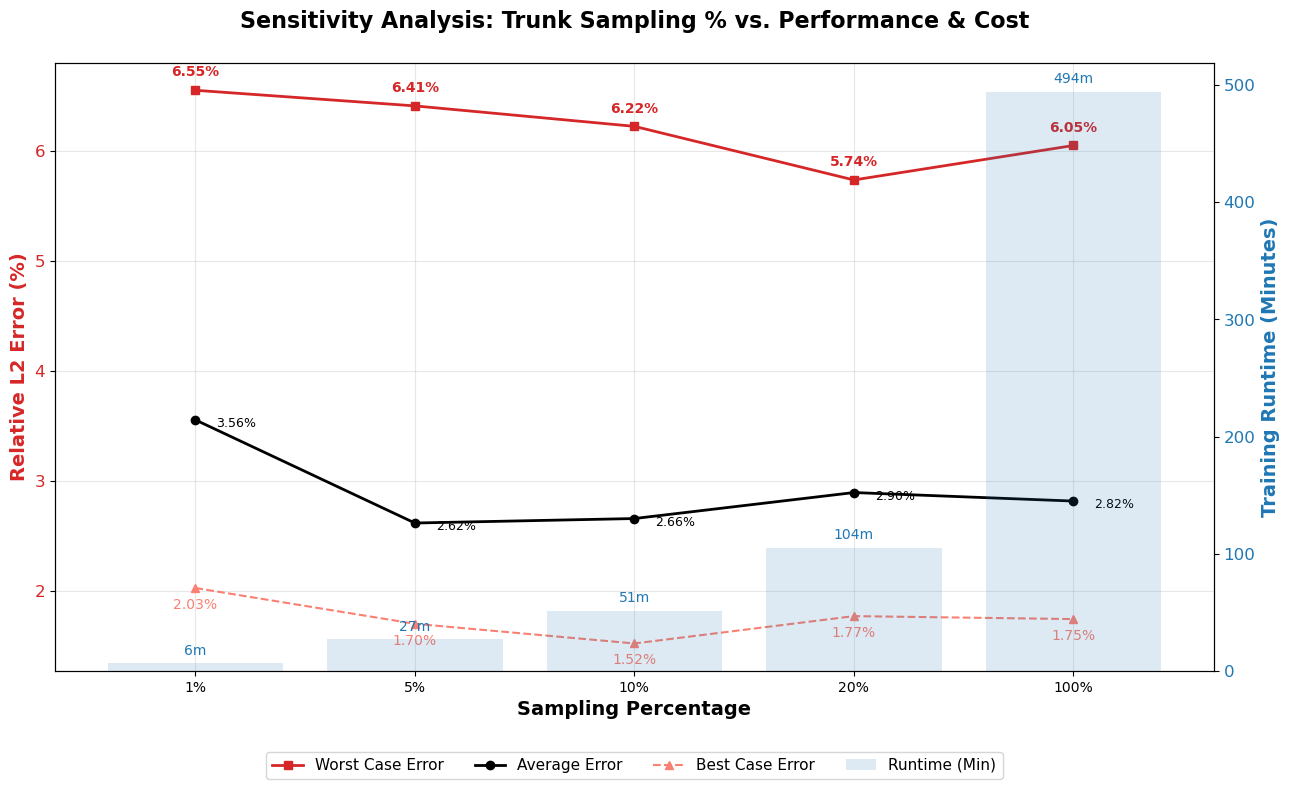

In [22]:
import matplotlib.pyplot as plt

# Data extraction (assuming your dictionaries are populated)
tiers = ["1p", "5p", "10p", "20p", "100p"]
tiers_label = ["1%", "5%", "10%", "20%", "100%"]
best_l2 = [sensitivity_results[t]['best'][0]['rel_l2'] for t in tiers]
worst_l2 = [sensitivity_results[t]['worst'][0]['rel_l2'] for t in tiers]
avg_errors = [sensitivity_results[t]['mean_l2'] for t in tiers]
runtimes = [runtime_seconds[t] / 60 for t in tiers] 

fig, ax1 = plt.subplots(figsize=(13, 8))

# --- Plot Accuracy (Line Chart) ---
ax1.set_xlabel('Sampling Percentage', fontsize=14, fontweight='bold')
ax1.set_ylabel('Relative L2 Error (%)', color='tab:red', fontsize=14, fontweight='bold')

# Plotting the three error lines
line1 = ax1.plot(tiers_label, worst_l2, color='tab:red', marker='s', linewidth=2, label='Worst Case Error')
line2 = ax1.plot(tiers_label, avg_errors, color='black', marker='o', linewidth=2, label='Average Error')
line3 = ax1.plot(tiers_label, best_l2, color='salmon', marker='^', linestyle='--', linewidth=1.5, label='Best Case Error')

ax1.tick_params(axis='y', labelcolor='tab:red', labelsize=12)
ax1.grid(True, alpha=0.3)

# --- Add Data Labels for Errors ---
for i in range(len(tiers_label)):
    # Worst case (Top)
    ax1.annotate(f'{worst_l2[i]:.2f}%', (tiers_label[i], worst_l2[i]), 
                 textcoords="offset points", xytext=(0,10), ha='center', color='tab:red', fontweight='bold')
    # Average (Middle/Side)
    ax1.annotate(f'{avg_errors[i]:.2f}%', (tiers_label[i], avg_errors[i]), 
                 textcoords="offset points", xytext=(15,-5), ha='left', fontsize=9)
    # Best case (Bottom)
    ax1.annotate(f'{best_l2[i]:.2f}%', (tiers_label[i], best_l2[i]), 
                 textcoords="offset points", xytext=(0,-15), ha='center', color='salmon')

# --- Plot Runtime (Bar Chart) ---
ax2 = ax1.twinx() 
ax2.set_ylabel('Training Runtime (Minutes)', color='tab:blue', fontsize=14, fontweight='bold')
bars = ax2.bar(tiers_label, runtimes, color='tab:blue', alpha=0.15, label='Runtime (Min)')
ax2.tick_params(axis='y', labelcolor='tab:blue', labelsize=12)

# --- Add Data Labels for Runtime ---
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{int(height)}m', ha='center', va='bottom', color='tab:blue', fontsize=10)

# --- Final Touches ---
plt.title('Sensitivity Analysis: Trunk Sampling % vs. Performance & Cost', fontsize=16, fontweight='bold', pad=25)

# Combined Legend
all_lines = line1 + line2 + line3
all_labels = [l.get_label() for l in all_lines] + ['Runtime (Min)']
ax1.legend(all_lines + [bars], all_labels, loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=4, fontsize=11)

fig.tight_layout()
plt.savefig('forces_different_percentage.pdf')
plt.show()